In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cost-of-international-education/International_Education_Costs.csv


In [5]:
file_path='/kaggle/input/cost-of-international-education/International_Education_Costs.csv'
df=pd.read_csv(file_path)

In [6]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Duration_Years,907.0,2.836825,0.945449,1.00,2.00,3.00,4.00,5.0
Tuition_USD,907.0,16705.016538,16582.385275,0.00,2850.00,7500.00,31100.00,62000.0
Living_Cost_Index,907.0,64.437486,14.056333,27.80,56.30,67.50,72.20,122.4
Rent_USD,907.0,969.206174,517.154752,150.00,545.00,900.00,1300.00,2500.0
Visa_Fee_USD,907.0,211.396913,143.435740,40.00,100.00,160.00,240.00,490.0
Insurance_USD,907.0,700.077178,320.374875,200.00,450.00,650.00,800.00,1500.0
Exchange_Rate,907.0,623.000695,3801.746134,0.15,0.92,1.35,7.15,42150.0


In [9]:
df.isnull().sum()

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [10]:
print(df.Country.unique()  )
print( df.Country.nunique())

['USA' 'UK' 'Canada' 'Australia' 'Germany' 'Japan' 'Netherlands'
 'Singapore' 'France' 'Switzerland' 'Sweden' 'Denmark' 'China'
 'South Korea' 'Ireland' 'New Zealand' 'Austria' 'Belgium' 'Hong Kong'
 'Portugal' 'Israel' 'Taiwan' 'Czech Republic' 'India' 'Poland' 'Malaysia'
 'Spain' 'Italy' 'Finland' 'Norway' 'Brazil' 'Turkey' 'Russia' 'Mexico'
 'Greece' 'Thailand' 'UAE' 'South Africa' 'Egypt' 'Argentina' 'Indonesia'
 'Saudi Arabia' 'Nigeria' 'Vietnam' 'Hungary' 'Iceland' 'Colombia'
 'Romania' 'Luxembourg' 'Tunisia' 'Cyprus' 'Croatia' 'Dominican Republic'
 'Morocco' 'Peru' 'Ecuador' 'Lebanon' 'Bahrain' 'Uruguay' 'Bulgaria'
 'Ghana' 'Algeria' 'Panama' 'Bangladesh' 'Kuwait' 'Ukraine' 'Slovenia'
 'Serbia' 'Iran' 'Uzbekistan' 'El Salvador']
71


In [11]:
df.Country.value_counts()

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Nigeria            1
Israel             1
Taiwan             1
South Africa       1
Czech Republic     1
Name: count, Length: 71, dtype: int64

<Axes: title={'center': 'Top 10 Country Highes Tuition Fee '}, ylabel='Country'>

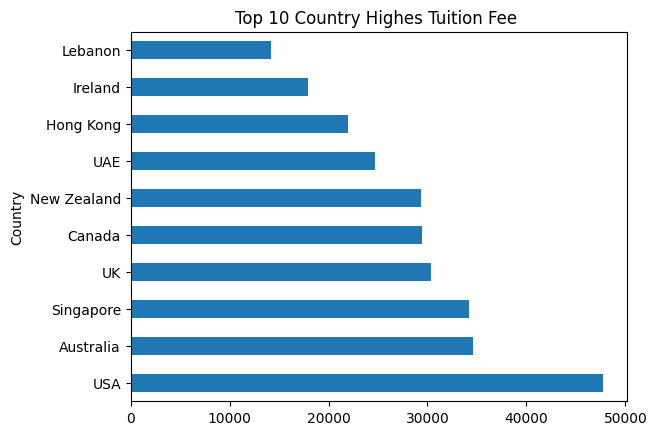

In [12]:
#('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')
df.groupby('Country')['Tuition_USD'].mean().sort_values(ascending=False).head(10).plot(kind='barh', title='Top 10 Country Highes Tuition Fee ')

<Axes: title={'center': 'Tuition Fee per Country'}, ylabel='Country'>

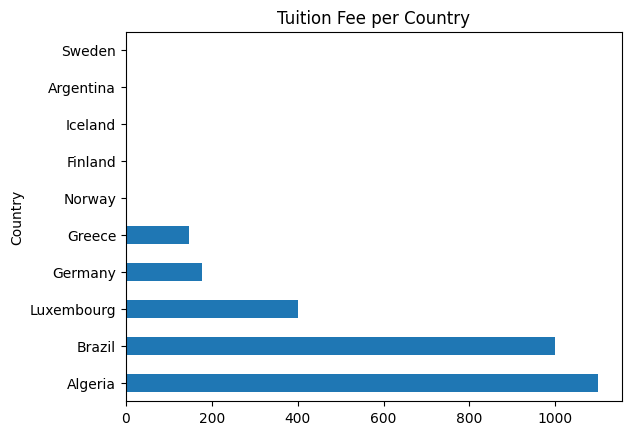

In [13]:
df.groupby('Country')['Tuition_USD'].mean().sort_values(ascending=False).tail(10).plot(kind='barh', title='Tuition Fee per Country')

In [14]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

In [15]:
df['Total_Expenses']=df['Living_Cost_Index']+df['Rent_USD']+df['Visa_Fee_USD']+df['Insurance_USD']
       

In [16]:
df.head(2)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Expenses
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,3943.5
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,3160.8


In [17]:
t_expenses=df.groupby('Country')['Total_Expenses'].mean().sort_values(ascending=False).head(50).reset_index()

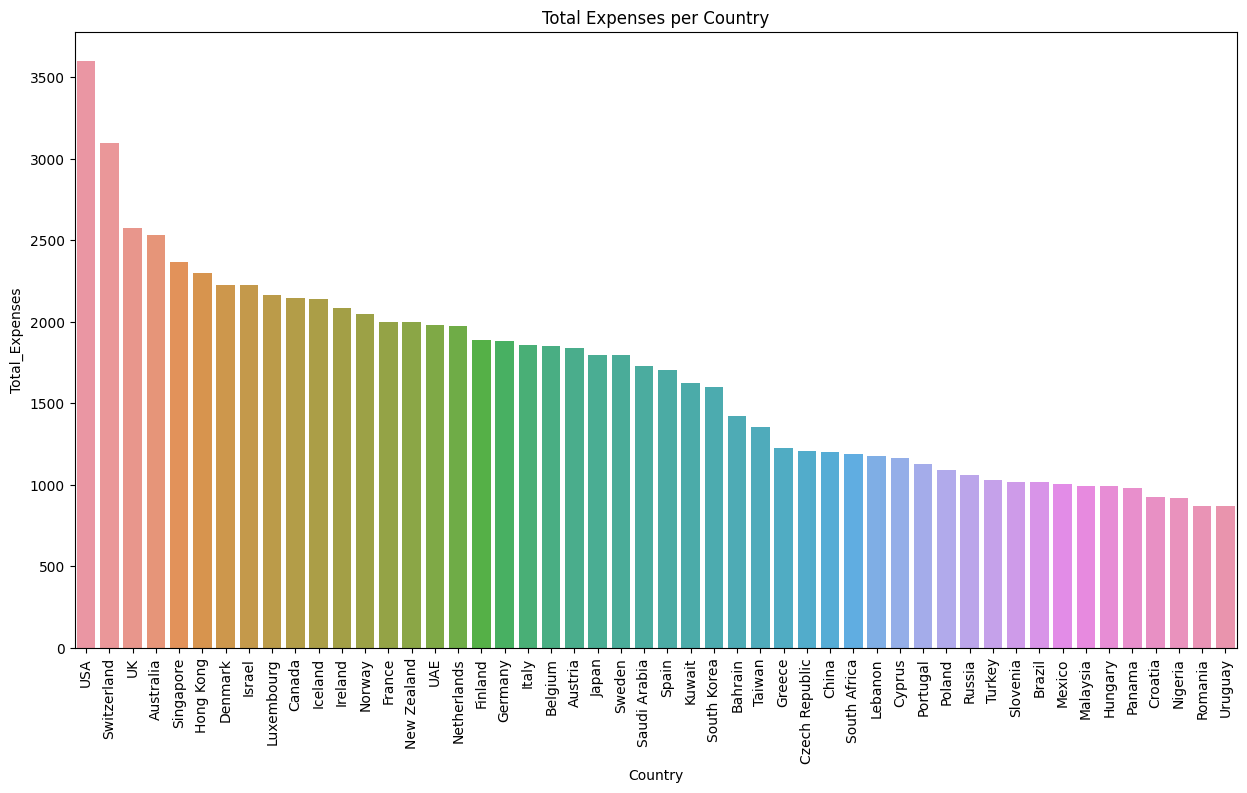

In [18]:
plt.figure(figsize=(15,8))
sns.barplot(x='Country', y='Total_Expenses', data=t_expenses)
plt.title('Total Expenses per Country')
plt.xticks(rotation=90);

In [19]:
t_expenses_les=df.groupby('Country')['Total_Expenses'].mean().sort_values(ascending=False).tail(50).reset_index()

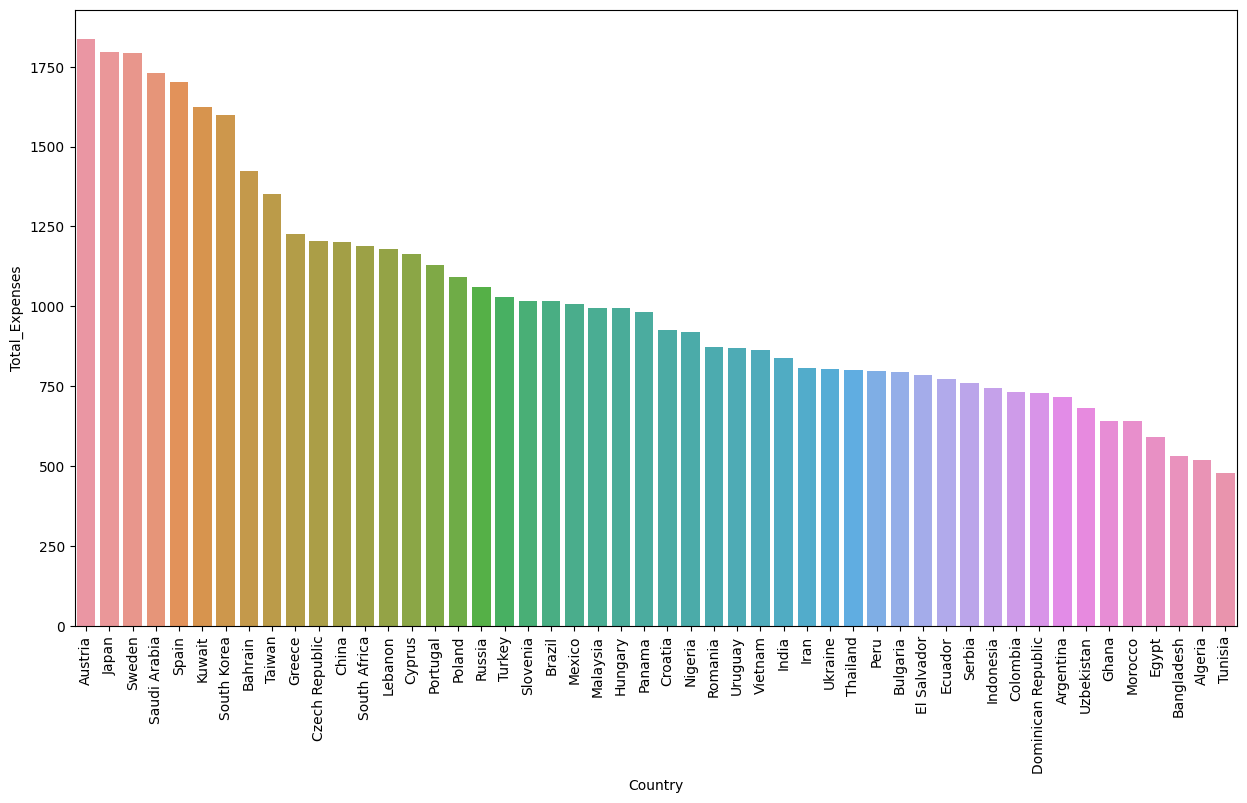

In [20]:
plt.figure(figsize=(15,8))
sns.barplot(x='Country', y='Total_Expenses', data=t_expenses_les)
plt.xticks(rotation=90);

In [21]:
df.pivot_table(values='Total_Expenses',index='City',aggfunc='sum' )

,Total_Expenses
City,
Aachen,5549.2
Aalborg,5646.4
Aarhus,4513.9
Aberdeen,2359.5
Abu Dhabi,2091.8
...,...
Zadar,903.2
Zagreb,988.9
Zaragoza,3086.4


In [23]:
df.isnull()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Expenses
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,False,False,False,False,False,False,False,False,False,False,False,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False,False
905,False,False,False,False,False,False,False,False,False,False,False,False,False


In [24]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Expenses
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,3943.5
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,3160.8
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35,2807.5
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52,2571.2
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92,1795.5


In [25]:
cols2 = ['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate']

<Axes: xlabel='Country,Level'>

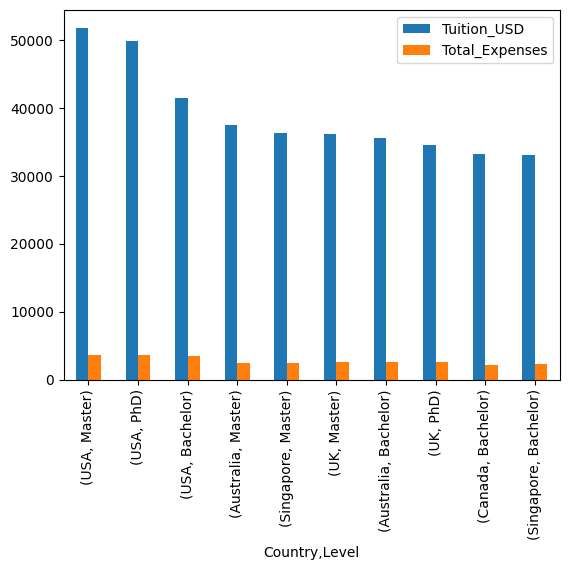

In [26]:
df.groupby(['Country','Level'])[['Tuition_USD','Total_Expenses']].mean().sort_values(by='Tuition_USD',ascending=False).head(10).plot(kind='bar')

In [27]:
df.groupby(['Country','Level'])[['Tuition_USD','Total_Expenses']].mean()

Tuition_USD  Total_Expenses
Country    Level                                
Algeria    Bachelor  1050.000000      520.850000
           Master    1050.000000      515.450000
           PhD       1300.000000      515.800000
Argentina  Bachelor     0.000000      770.050000
           Master       0.000000      679.150000
...                          ...             ...
Uruguay    Master    4500.000000      858.066667
           PhD          0.000000      942.400000
Uzbekistan Bachelor  3850.000000      712.150000
           Master    3466.666667      659.166667
Vietnam    Bachelor  3200.000000      863.600000

[187 rows x 2 columns]

In [28]:
country=df.groupby('Country')
country.get_group('Vietnam')

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Expenses
140,Vietnam,Ho Chi Minh City,HCMUT,Software Engineering,Bachelor,4.0,3200,43.6,450,120,250,24450.0,863.6


In [29]:
country.get_group('China')[['City','Tuition_USD']].reset_index()


,index,City,Tuition_USD
0,12,Beijing,8900
1,133,Shenzhen,8200
2,184,Beijing,8900
3,185,Beijing,8500
4,186,Shanghai,7800
5,187,Shanghai,8200
6,188,Hangzhou,7500
7,189,Nanjing,7200
8,190,Guangzhou,6900
9,191,Wuhan,6500


In [30]:
df.groupby('Country')['Living_Cost_Index'].mean().sort_values(ascending=False)

Country
Switzerland    97.820000
Singapore      82.022222
Iceland        81.750000
Luxembourg     78.900000
Hong Kong      78.600000
                 ...    
Ghana          38.520000
Colombia       36.983333
Algeria        35.680000
Tunisia        32.266667
Egypt          31.142857
Name: Living_Cost_Index, Length: 71, dtype: float64

In [31]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate', 'Total_Expenses'],
      dtype='object')

<Axes: ylabel='count'>

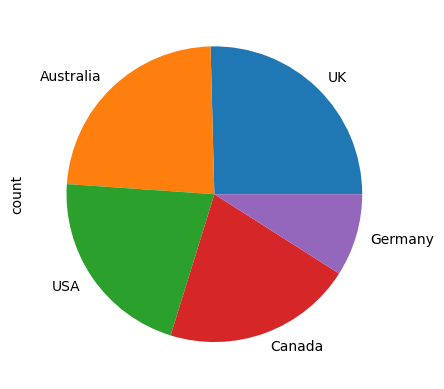

In [34]:
df.Country.value_counts().head().plot(kind='pie')

In [41]:
co=df.groupby('Country')['Tuition_USD'].mean()

<Axes: title={'center': 'Tuition per COUNTRY'}, xlabel='Country'>

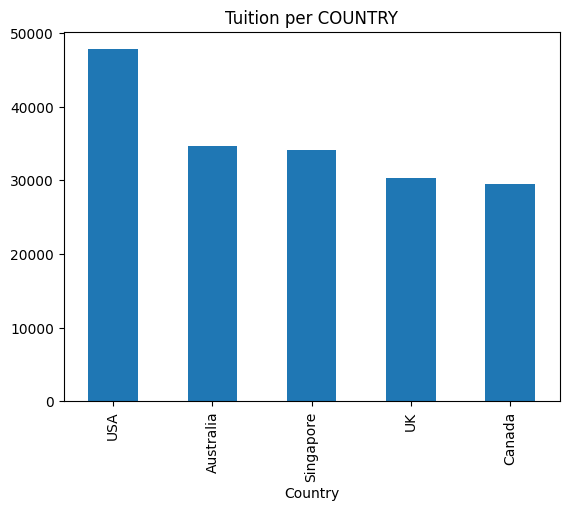

In [47]:
co.sort_values(ascending=False).head().plot(kind='bar', title='Tuition per COUNTRY')


In [61]:
four=df[df.Duration_Years>=4]
print(f'Maximum Tuititon fee',four.Tuition_USD.max(), 'Minimum Tuititon fee',four.Tuition_USD.min()>0)

Maximum Tuititon fee 57000 Minimum Tuititon fee False
